<a href="https://colab.research.google.com/github/navisasabina/ml-demand-forecasting/blob/main/machine_learning_navisa_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Promo & Holiday Effects in E-Commerce: Uplift-Aware Forecasts with Regression, DT, and Neural Networks Machine Learning Solution for Customer Demand Prediction

  

sel 0

In [ ]:
import warnings, os, sys, math, json
warnings.filterwarnings("ignore")
SEED = 42


sel 1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/online_retail_II.xlsx"
assert os.path.exists(DATA_PATH), "Fix DATA_PATH to point to your Excel file."


Mounted at /content/drive


sel 2

In [ ]:
import pandas as pd
import numpy as np

xls = pd.ExcelFile(DATA_PATH)
dfs = []
for sh in xls.sheet_names:
    df = pd.read_excel(xls, sh)
    df['Sheet'] = sh
    dfs.append(df)
raw = pd.concat(dfs, ignore_index=True)

# Basic cleaning
df = raw.copy()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df = df.dropna(subset=['InvoiceDate', 'Quantity', 'Price'])
# remove cancellations (Invoice starting with 'C') and non-positive quantities/prices
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# revenue per row
df['Revenue'] = df['Quantity'] * df['Price']

# keep only plausibly valid stock codes (alphanumeric)
df = df[df['StockCode'].astype(str).str.match(r'^[A-Za-z0-9]+$')]

# Fill missing text columns
for c in ['Description','Country','Customer ID']:
    if c in df.columns:
        if c == 'Customer ID':
            df[c] = df[c].astype('float').round().astype('Int64')
        else:
            df[c] = df[c].astype(str).fillna('')

print(df.shape, df['InvoiceDate'].min(), df['InvoiceDate'].max())
df.head()


(1041557, 10) 2009-12-01 07:45:00 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sheet,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,Year 2009-2010,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,Year 2009-2010,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,Year 2009-2010,30.0


sel 3

In [ ]:
# --- Promo flag per line ---
sku_median_price = df.groupby('StockCode')['Price'].median().rename('sku_price_median')
df = df.merge(sku_median_price, on='StockCode', how='left')
df['promo_line'] = (df['Price'] < 0.9 * df['sku_price_median']).astype(int)

# --- Holidays (UK) ---
import holidays
uk_holidays = holidays.UnitedKingdom(years=list(range(df['InvoiceDate'].dt.year.min(),
                                                     df['InvoiceDate'].dt.year.max()+1)))
df['Date'] = df['InvoiceDate'].dt.date
df['is_holiday'] = df['Date'].apply(lambda d: int(d in uk_holidays))

# --- Daily aggregation (Store-level; you can switch to per-country later) ---
daily = df.groupby('Date').agg(
    daily_revenue = ('Revenue','sum'),
    transactions  = ('Invoice','nunique'),
    items_sold    = ('Quantity','sum'),
    unique_skus   = ('StockCode','nunique'),
    promo_share   = ('promo_line','mean'),
    is_holiday    = ('is_holiday','max'),
).reset_index()

# Calendar features
ds = pd.to_datetime(daily['Date'])
daily['dow'] = ds.dt.weekday       # 0=Mon
daily['is_weekend'] = daily['dow'].isin([5,6]).astype(int)
daily['weekofyear'] = ds.dt.isocalendar().week.astype(int)
daily['month'] = ds.dt.month
daily['year'] = ds.dt.year

# Lag features (leak-safe for forecasting same-day)
for L in [1,7,14]:
    daily[f'rev_lag_{L}'] = daily['daily_revenue'].shift(L)
    daily[f'promo_lag_{L}'] = daily['promo_share'].shift(L)

# Rolling stats
daily['rev_roll7_mean'] = daily['daily_revenue'].rolling(7, min_periods=2).mean()
daily['rev_roll14_mean'] = daily['daily_revenue'].rolling(14, min_periods=2).mean()

# Define treatment as "promo day" if promo_share above threshold
PROMO_DAY_THRESHOLD = 0.05
daily['treatment_promo_day'] = (daily['promo_share'] >= PROMO_DAY_THRESHOLD).astype(int)

# Drop first rows with NaNs from lags/rolls
daily = daily.dropna().reset_index(drop=True)
daily.head()


,Date,daily_revenue,transactions,items_sold,unique_skus,promo_share,is_holiday,dow,is_weekend,weekofyear,...,year,rev_lag_1,promo_lag_1,rev_lag_7,promo_lag_7,rev_lag_14,promo_lag_14,rev_roll7_mean,rev_roll14_mean,treatment_promo_day
0,2009-12-16,52792.25,98,25006,1420,0.072030,0,2,0,51,...,2009,50340.24,0.115053,49502.23,0.083181,54513.50,0.065056,46198.100000,45036.593571,1
1,2009-12-17,31239.47,104,15593,1037,0.099143,0,3,0,51,...,2009,52792.25,0.072030,40616.09,0.060008,63352.51,0.066154,44858.582857,42742.805000,1
2,2009-12-18,42518.53,68,17442,1116,0.072906,0,4,0,51,...,2009,31239.47,0.099143,44442.11,0.082397,74037.91,0.051256,44583.785714,40491.420714,1
3,2009-12-20,11450.68,34,6263,464,0.084395,0,6,1,51,...,2009,42518.53,0.072906,39659.60,0.149409,40732.92,0.049446,40553.940000,38399.832143,1
4,2009-12-21,16367.84,41,8790,454,0.124394,0,0,0,52,...,2009,11450.68,0.084395,22313.09,0.061121,9803.05,0.267500,39704.618571,38868.745714,1


sel 4

In [ ]:
# Sort by time
daily = daily.sort_values('Date').reset_index(drop=True)

# Target
TARGET = 'daily_revenue'

# Feature set
feat_cols = [
    'transactions','items_sold','unique_skus','promo_share','is_holiday',
    'dow','is_weekend','weekofyear','month',
    'rev_lag_1','rev_lag_7','rev_lag_14',
    'promo_lag_1','promo_lag_7','promo_lag_14',
    'rev_roll7_mean','rev_roll14_mean',
    'treatment_promo_day'
]

X = daily[feat_cols].astype(float)
y = daily[TARGET].astype(float)

# Time-based split: 70% train, 15% val, 15% test
n = len(daily)
i_tr = int(0.70*n)
i_va = int(0.85*n)
X_tr, y_tr = X.iloc[:i_tr], y.iloc[:i_tr]
X_va, y_va = X.iloc[i_tr:i_va], y.iloc[i_tr:i_va]
X_te, y_te = X.iloc[i_va:], y.iloc[i_va:]

print(X_tr.shape, X_va.shape, X_te.shape)


(413, 18) (88, 18) (89, 18)


sel 5

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

def eval_reg(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Scale only continuous features (trees don't need scaling but harmless in a single pipeline)
scale_cols = feat_cols
prepro = ColumnTransformer([
    ('sc', StandardScaler(with_mean=True, with_std=True), scale_cols)
], remainder='drop')

sel 6

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import ElasticNet


enet = Pipeline([
    ('pp', prepro),
    ('mdl', ElasticNet(max_iter=10000, random_state=SEED))
])

tscv = TimeSeriesSplit(n_splits=5) # Increased splits for potentially better evaluation
enet_grid = {
    'mdl__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0], # Expanded range
    'mdl__l1_ratio': [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 0.99] # Expanded range
}

enet_cv = GridSearchCV(enet, enet_grid, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
enet_cv.fit(X_tr, y_tr)

y_hat_va = enet_cv.predict(X_va)
y_hat_te = enet_cv.predict(X_te)

enet_res = {
  'val': eval_reg(y_va, y_hat_va),
  'test': eval_reg(y_te, y_hat_te),
  'best_params': enet_cv.best_params_
}
enet_res

{'val': {'RMSE': np.float64(7085.269901279328),
  'MAE': 4967.296989773464,
  'R2': 0.7271239391467291},
 'test': {'RMSE': np.float64(14078.440618262264),
  'MAE': 8321.745531337157,
  'R2': 0.7033487988094829},
 'best_params': {'mdl__alpha': 1.0, 'mdl__l1_ratio': 0.99}}

sel 7

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor

tree = Pipeline([
    ('pp', prepro),  # not necessary, but consistent
    ('mdl', DecisionTreeRegressor(random_state=SEED))
])

tscv = TimeSeriesSplit(n_splits=5) # Increased splits for potentially better evaluation
tree_grid = {
    'mdl__max_depth': [3, 4, 6, 8, 12, 15, None], # Expanded range
    'mdl__min_samples_split': [2, 5, 10, 25, 50], # Expanded range
    'mdl__min_samples_leaf': [1, 2, 5, 10, 20] # Expanded range
}

tree_cv = GridSearchCV(tree, tree_grid, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
tree_cv.fit(X_tr, y_tr)

y_hat_va = tree_cv.predict(X_va)
y_hat_te = tree_cv.predict(X_te)

tree_res = {
  'val': eval_reg(y_va, y_hat_va),
  'test': eval_reg(y_te, y_hat_te),
  'best_params': tree_cv.best_params_
}
tree_res

{'val': {'RMSE': np.float64(7669.731881989486),
  'MAE': 4746.47434925682,
  'R2': 0.6802481953673098},
 'test': {'RMSE': np.float64(16692.88179657229),
  'MAE': 11255.705658378343,
  'R2': 0.5829389418773574},
 'best_params': {'mdl__max_depth': 4,
  'mdl__min_samples_leaf': 2,
  'mdl__min_samples_split': 10}}

sel 8

In [ ]:
from xgboost import XGBRegressor

xgb = Pipeline([
    ('pp', prepro),
    ('mdl', XGBRegressor(
        n_estimators=500, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
        max_depth=6, random_state=SEED, tree_method='hist'
    ))
])

xgb_grid = {
    'mdl__max_depth': [4, 6, 8],
    'mdl__learning_rate': [0.03, 0.05, 0.1],
    'mdl__n_estimators': [300, 500, 800]
}

xgb_cv = GridSearchCV(xgb, xgb_grid, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
xgb_cv.fit(X_tr, y_tr)

y_hat_va = xgb_cv.predict(X_va)
y_hat_te = xgb_cv.predict(X_te)

xgb_res = {
  'val': eval_reg(y_va, y_hat_va),
  'test': eval_reg(y_te, y_hat_te),
  'best_params': xgb_cv.best_params_
}
xgb_res


{'val': {'RMSE': np.float64(6256.568351144099),
  'MAE': 4074.675482466264,
  'R2': 0.7872228307412471},
 'test': {'RMSE': np.float64(12638.683093693404),
  'MAE': 7543.179054336375,
  'R2': 0.7609214279846113},
 'best_params': {'mdl__learning_rate': 0.03,
  'mdl__max_depth': 4,
  'mdl__n_estimators': 800}}

sel 9

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.neural_network import MLPRegressor

mlp = Pipeline([
    ('pp', prepro),
    ('mdl', MLPRegressor(
        activation='relu',
        solver='adam',
        max_iter=1000, # Increased max_iter
        random_state=SEED,
        early_stopping=True, # Add early stopping to prevent overfitting
        n_iter_no_change=20 # Patience parameter for early stopping
    ))
])

tscv = TimeSeriesSplit(n_splits=5)
mlp_grid = {
    'mdl__hidden_layer_sizes': [(64,), (128,), (64,64), (128,64), (256,128), (128,64,32)],
    'mdl__alpha': [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
    'mdl__learning_rate_init': [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
}

mlp_cv = GridSearchCV(mlp, mlp_grid, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
mlp_cv.fit(X_tr, y_tr)

y_hat_va = mlp_cv.predict(X_va)
y_hat_te = mlp_cv.predict(X_te)

mlp_res = {
  'val': eval_reg(y_va, y_hat_va),
  'test': eval_reg(y_te, y_hat_te),
  'best_params': mlp_cv.best_params_
}
mlp_res

{'val': {'RMSE': np.float64(9258.741937686827),
  'MAE': 6636.455962585845,
  'R2': 0.5340314570912941},
 'test': {'RMSE': np.float64(14894.900677085887),
  'MAE': 8722.860806421322,
  'R2': 0.6679433152134426},
 'best_params': {'mdl__alpha': 0.01,
  'mdl__hidden_layer_sizes': (128, 64, 32),
  'mdl__learning_rate_init': 0.01}}

sel 10

In [ ]:
res_tbl = pd.DataFrame({
    'Model': ['ElasticNet','DecisionTree','XGBoost','MLP'],
    'Val_RMSE': [enet_res['val']['RMSE'], tree_res['val']['RMSE'], xgb_res['val']['RMSE'] if 'xgb_res' in globals() else np.nan, mlp_res['val']['RMSE']],
    'Test_RMSE':[enet_res['test']['RMSE'], tree_res['test']['RMSE'], xgb_res['test']['RMSE'] if 'xgb_res' in globals() else np.nan, mlp_res['test']['RMSE']],
    'Val_MAE':  [enet_res['val']['MAE'],  tree_res['val']['MAE'],  xgb_res['val']['MAE'] if 'xgb_res' in globals() else np.nan, mlp_res['val']['MAE']],
    'Test_MAE': [enet_res['test']['MAE'], tree_res['test']['MAE'], xgb_res['test']['MAE'] if 'xgb_res' in globals() else np.nan, mlp_res['test']['MAE']],
    'Val_R2':   [enet_res['val']['R2'],   tree_res['val']['R2'],   xgb_res['val']['R2'] if 'xgb_res' in globals() else np.nan, mlp_res['val']['R2']],
    'Test_R2':  [enet_res['test']['R2'],  tree_res['test']['R2'],  xgb_res['test']['R2'] if 'xgb_res' in globals() else np.nan, mlp_res['test']['R2']]
})
res_tbl.sort_values('Test_RMSE', inplace=True)
res_tbl


,Model,Val_RMSE,Test_RMSE,Val_MAE,Test_MAE,Val_R2,Test_R2
2,XGBoost,6256.568351,12638.683094,4074.675482,7543.179054,0.787223,0.760921
0,ElasticNet,7085.269901,14078.440618,4967.296990,8321.745531,0.727124,0.703349
3,MLP,9258.741938,14894.900677,6636.455963,8722.860806,0.534031,0.667943
1,DecisionTree,7669.731882,16692.881797,4746.474349,11255.705658,0.680248,0.582939


sel 11

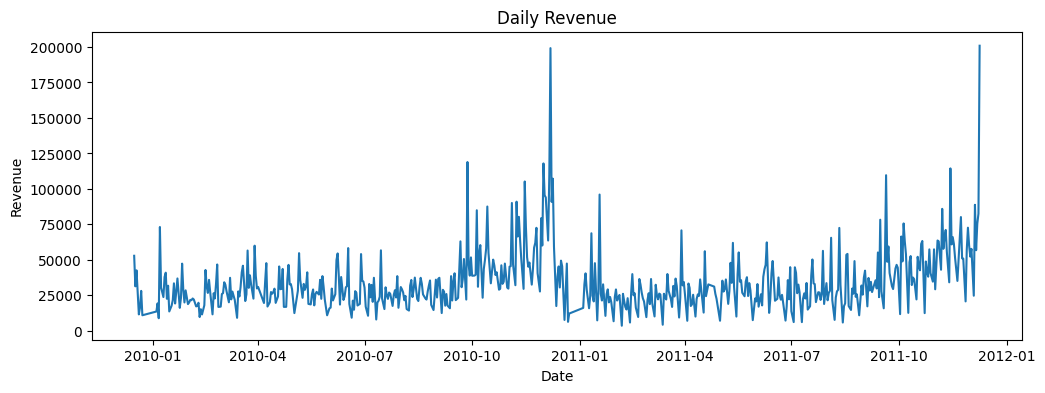

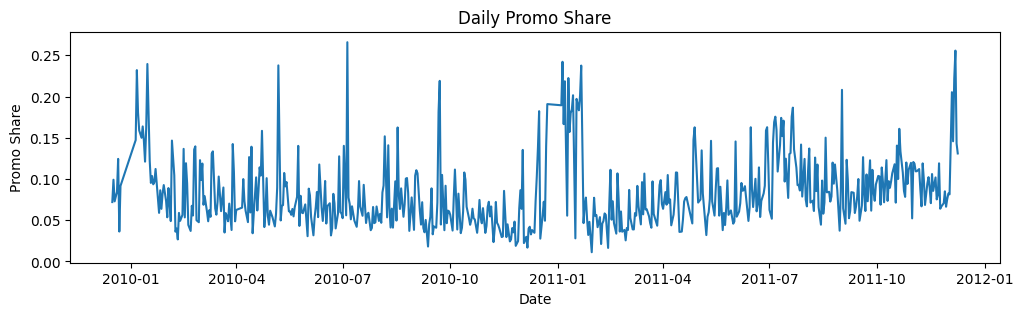

Best by Test RMSE: XGBoost


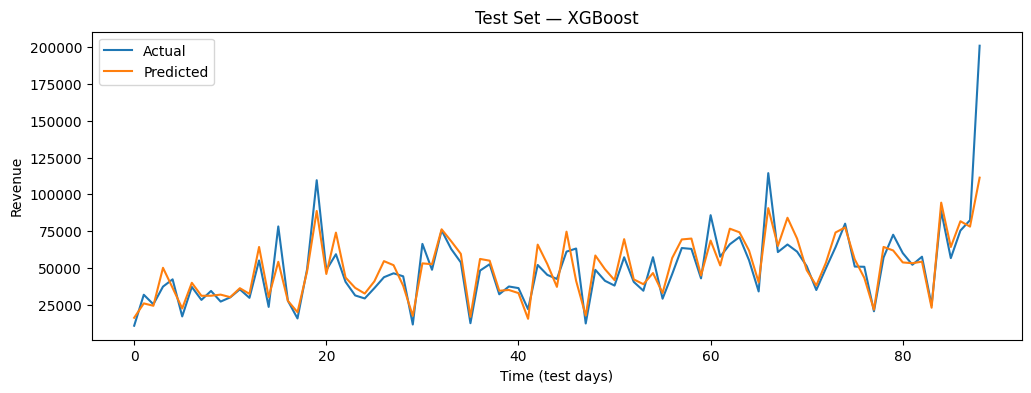

In [ ]:
import matplotlib.pyplot as plt

# EDA: revenue with holidays & promo days
fig = plt.figure(figsize=(12,4))
plt.plot(pd.to_datetime(daily['Date']), daily['daily_revenue'])
plt.title("Daily Revenue")
plt.xlabel("Date"); plt.ylabel("Revenue")
plt.show()

fig = plt.figure(figsize=(12,3))
plt.plot(pd.to_datetime(daily['Date']), daily['promo_share'])
plt.title("Daily Promo Share")
plt.xlabel("Date"); plt.ylabel("Promo Share")
plt.show()

# Best model predictions on TEST (use XGBoost if available, else best by RMSE)
best_model_name = res_tbl.iloc[0]['Model']
print("Best by Test RMSE:", best_model_name)

if best_model_name == 'XGBoost' and 'xgb_cv' in globals():
    best_model = xgb_cv.best_estimator_
elif best_model_name == 'MLP':
    best_model = mlp_cv.best_estimator_
elif best_model_name == 'DecisionTree':
    best_model = tree_cv.best_estimator_
else:
    best_model = enet_cv.best_estimator_

y_hat_test_best = best_model.predict(X_te)

fig = plt.figure(figsize=(12,4))
plt.plot(y_te.values, label='Actual')
plt.plot(y_hat_test_best, label='Predicted')
plt.title(f"Test Set — {best_model_name}")
plt.xlabel("Time (test days)"); plt.ylabel("Revenue"); plt.legend()
plt.show()


sel 12

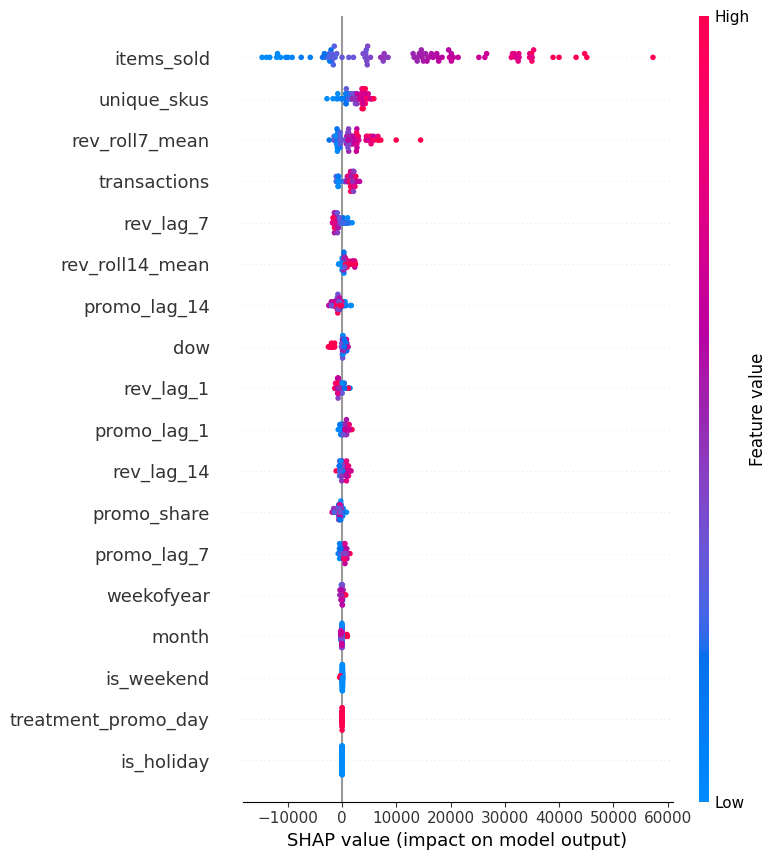

In [ ]:
# If using XGBoost: native feature importances
if best_model_name == 'XGBoost' and 'xgb_cv' in globals():
    mdl = best_model.named_steps['mdl']
    importances = mdl.feature_importances_
    fi = pd.DataFrame({'feature': scale_cols, 'importance': importances}).sort_values('importance', ascending=False)
    fi.head(15)

# SHAP (works well with tree models)
try:
    import shap
    if best_model_name == 'XGBoost':
        explainer = shap.TreeExplainer(mdl)
        shap_values = explainer.shap_values(best_model.named_steps['pp'].transform(X_te))
        shap.summary_plot(shap_values, best_model.named_steps['pp'].transform(X_te), feature_names=scale_cols)
except Exception as e:
    print("SHAP plot skipped:", e)


sel 13

In [ ]:
from sklearn.base import clone

T = daily['treatment_promo_day'].values.astype(int)
X_np = X.values
Y = y.values

# Same prepro for both learners
base_reg = XGBRegressor(
    n_estimators=400, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
    max_depth=6, random_state=SEED, tree_method='hist'
)

# Learner for treated
mdl_T = Pipeline([('pp', prepro), ('mdl', clone(base_reg))])
# Learner for control
mdl_C = Pipeline([('pp', prepro), ('mdl', clone(base_reg))])

# Fit on TRAIN+VAL only (time-aware)
X_trva, Y_trva, T_trva = pd.concat([X_tr, X_va]), pd.concat([y_tr, y_va]), np.concatenate([T[:len(X_tr)], T[len(X_tr):len(X_tr)+len(X_va)]])
mdl_T.fit(X_trva[T_trva==1], Y_trva[T_trva==1])
mdl_C.fit(X_trva[T_trva==0], Y_trva[T_trva==0])

# Uplift on TEST: E[Y|T=1,X] - E[Y|T=0,X]
mu1 = mdl_T.predict(X_te)
mu0 = mdl_C.predict(X_te)
uplift = mu1 - mu0

uplift_df = pd.DataFrame({
    'Date': daily['Date'].iloc[len(X_tr)+len(X_va):].values,
    'uplift_pred': uplift,
    'is_holiday': daily['is_holiday'].iloc[len(X_tr)+len(X_va):].values,
    'promo_share': daily['promo_share'].iloc[len(X_tr)+len(X_va):].values
})
uplift_df.head()


,Date,uplift_pred,is_holiday,promo_share
0,2011-08-28,-1136.193359,0,0.086120
1,2011-08-30,-2284.689453,0,0.037337
2,2011-08-31,195.404297,0,0.084702
3,2011-09-01,7734.449219,0,0.208155
4,2011-09-02,5583.941406,0,0.064461


sel 14

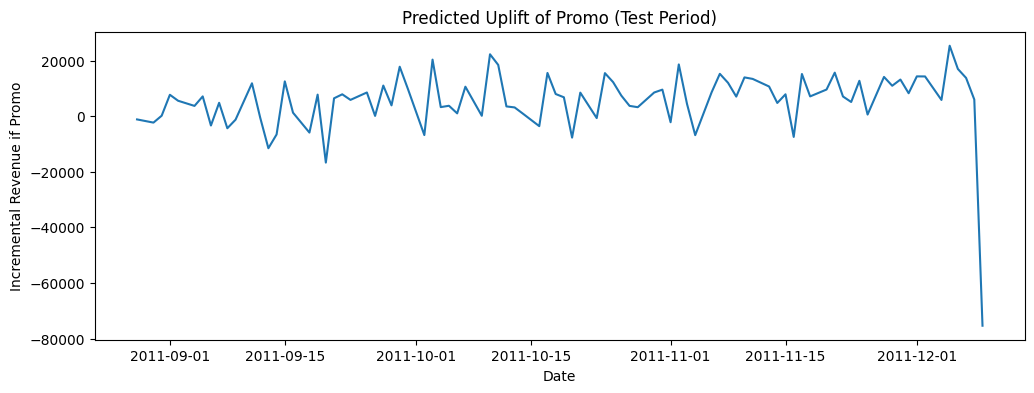

Avg uplift on promo days: 5,681.45 ; on non-promo days: 909.69


In [ ]:
# Visualize uplift predictions over test horizon
fig = plt.figure(figsize=(12,4))
plt.plot(pd.to_datetime(uplift_df['Date']), uplift_df['uplift_pred'])
plt.title("Predicted Uplift of Promo (Test Period)")
plt.xlabel("Date"); plt.ylabel("Incremental Revenue if Promo")
plt.show()

# Simple sanity: average uplift on heavy-promo vs low-promo test days
hi = uplift_df['uplift_pred'][uplift_df['promo_share']>=PROMO_DAY_THRESHOLD].mean()
lo = uplift_df['uplift_pred'][uplift_df['promo_share']<PROMO_DAY_THRESHOLD].mean()
print(f"Avg uplift on promo days: {hi:,.2f} ; on non-promo days: {lo:,.2f}")


sel 15

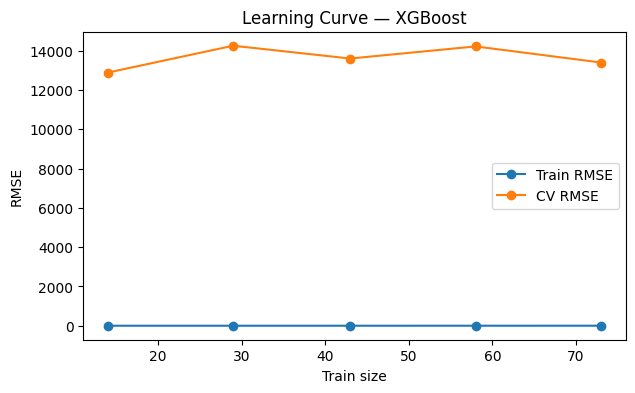

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X_, y_, title):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X_, y_, cv=tscv, scoring='neg_root_mean_squared_error',
        train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1
    )
    train_rmse = -train_scores.mean(axis=1)
    val_rmse   = -val_scores.mean(axis=1)

    fig = plt.figure(figsize=(7,4))
    plt.plot(train_sizes, train_rmse, marker='o', label='Train RMSE')
    plt.plot(train_sizes, val_rmse, marker='o', label='CV RMSE')
    plt.title(title); plt.xlabel("Train size"); plt.ylabel("RMSE"); plt.legend(); plt.show()

plot_learning_curve(best_model, X_tr, y_tr, f"Learning Curve — {best_model_name}")


sel 16

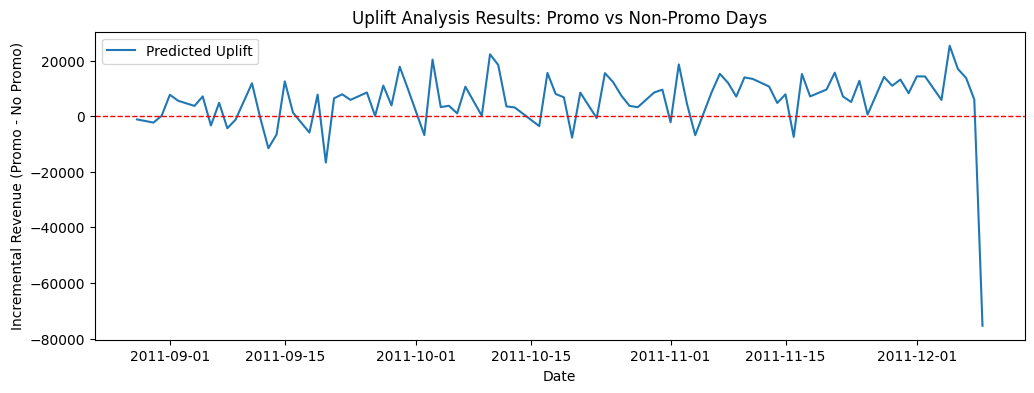

In [ ]:
import matplotlib.pyplot as plt

# Plot uplift predictions over test horizon
plt.figure(figsize=(12,4))
plt.plot(pd.to_datetime(uplift_df['Date']), uplift_df['uplift_pred'], label="Predicted Uplift")
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Uplift Analysis Results: Promo vs Non-Promo Days")
plt.xlabel("Date")
plt.ylabel("Incremental Revenue (Promo - No Promo)")
plt.legend()
plt.show()


sel 17

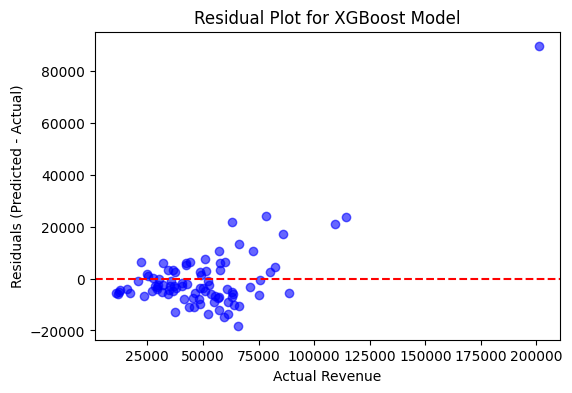

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
# Calculate residuals
residuals = y_te - y_hat_test_best
plt.scatter(y_te, residuals, alpha=0.6, color='blue')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Actual Revenue")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("Residual Plot for XGBoost Model")
plt.show()

sel 18

In [ ]:
import time

def time_fit(model, X_, y_):
    t0 = time.time(); model.fit(X_, y_); return time.time()-t0

cards = {}
for name, cvobj in [('ElasticNet', enet_cv), ('DecisionTree', tree_cv), ('XGBoost', xgb_cv if 'xgb_cv' in globals() else None), ('MLP', mlp_cv)]:
    if cvobj is None: continue
    best = cvobj.best_estimator_
    tr_time = time_fit(best, X_tr, y_tr)
    cards[name] = {
        'best_params': cvobj.best_params_,
        'train_seconds': round(tr_time,2),
        'n_features': X.shape[1]
    }

pd.DataFrame(cards).T


,best_params,train_seconds,n_features
ElasticNet,"{'mdl__alpha': 1.0, 'mdl__l1_ratio': 0.99}",0.01,18
DecisionTree,"{'mdl__max_depth': 4, 'mdl__min_samples_leaf':...",0.01,18
XGBoost,"{'mdl__learning_rate': 0.03, 'mdl__max_depth':...",0.85,18
MLP,"{'mdl__alpha': 0.01, 'mdl__hidden_layer_sizes'...",1.22,18
